In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import pandas as pd
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

from keras.layers import Input, Dense
from keras.models import Model
from keras.models import Sequential
from keras.utils import to_categorical
from keras.optimizers import SGD

Using TensorFlow backend.


In [2]:
""" I want to plot somewhat randomized datasets for use in classification visualizations. 
    For now I'll focus on three geometric shapes, ranging from least complicated to most.
    
    The least complicated shape will be a dataset with two classes that can be separated 
    by two planes (like a hinged plane).
    After that, I'll make a dataset that can be separated by a paraboloid.
    Finally, I'll make a dataset that can be separated by a sinusoidal surface.
    
    Each dataset may have some overlap between classes due to random noise.
"""

class Shape:
    def __init__(this):
        # Generate 2 random sets of (x,y) coordinates
        this.class0 = pd.DataFrame(9*np.random.rand(50,2), columns = ['x','y'])
        this.class1 = pd.DataFrame(9*np.random.rand(50,2), columns = ['x','y'])
        
        # Generate the hinged planes
        this.class0['z_plane'] = [y - 9*np.random.rand() if y > 4 else 3.9*np.random.rand() for y in this.class0['y']]
        this.class1['z_plane'] = [y + 3*np.random.rand() if y > 4 else 4.1*np.random.rand() + 4 for y in this.class1['y']]
        
        # Generate the paraboloid data
        this.class0['z_para'] = [-0.5*(y-4.5)**2*np.random.rand() + 3 for y in this.class0['y']]
        this.class1['z_para'] = [-0.5*(y-4.5)**2*np.random.rand() + 6 for y in this.class1['y']]
        
        # Generate the sinusoidal data
        this.class0['z_sin'] = [np.sin(2*y)*np.random.rand() + 3 for y in this.class0['y']]
        this.class1['z_sin'] = [np.sin(2*y)*np.random.rand() + 4 for y in this.class1['y']]
        
        # Assign the class labels
        this.class0['label'] = 0
        this.class1['label'] = 1
        
    def plot(this, kind = 'z_plane'):
        """ Generate the 3D shape with two classes. """
        
        if kind in ['z_plane','z_para','z_sin']:
            %matplotlib notebook

            fig = plt.figure()
            ax = fig.add_subplot(111, projection='3d')

            ax.scatter(this.class0['x'], this.class0['y'], this.class0[kind], color = 'r')
            ax.scatter(this.class1['x'], this.class1['y'], this.class1[kind], color = 'b')

            ax.set_xlabel('$X$')
            ax.set_ylabel('$Y$');
            ax.set_zlabel('$Z$');
            
        return None
    
    def prep(this, kind = 'z_plane'):
        """ Prepare the data for use with keras """
        
        this.data = pd.concat([this.class0, this.class1])
        this.data.index = np.arange(len(this.data))
        
        this.x_train = this.data[['x','y',kind]].loc[:49]
        this.x_test = this.data[['x','y',kind]].loc[50:]
        
        this.y_train = this.data['label'].loc[:49].to_numpy()
        this.y_test = this.data['label'].loc[50:].to_numpy()
                
        this.y_train = to_categorical(this.y_train, 2)
        this.y_test = to_categorical(this.y_test, 2)
                
        return None

<IPython.core.display.Javascript object>


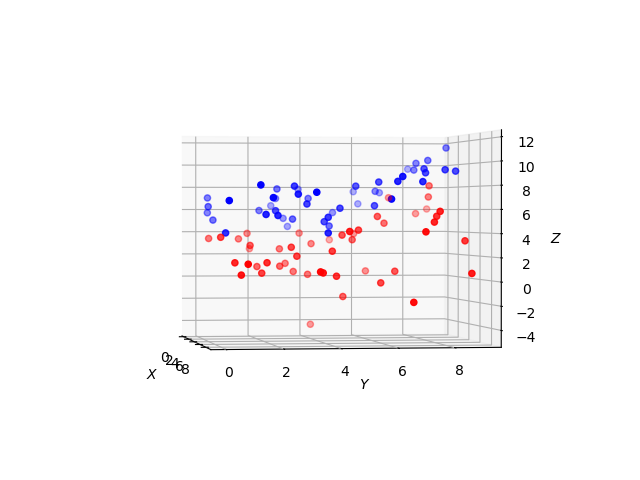

In [3]:
data = Shape()
data.prep()
data.plot()

In [4]:
model = Sequential()
model.add(Dense(3, activation = 'relu', input_shape = (3,)))
model.add(Dense(2, activation = 'softmax'))

model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_1 (Dense)              (None, 3)                 12        
_________________________________________________________________
dense_2 (Dense)              (None, 2)                 8         
Total params: 20
Trainable params: 20
Non-trainable params: 0
_________________________________________________________________


In [5]:
model.compile(loss='binary_crossentropy',
              optimizer=SGD(),
              metrics=['accuracy'])

In [6]:
epochs = 2
batch_size = 10

history = model.fit(data.x_train, data.y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(data.x_test, data.y_test))
score = model.evaluate(data.x_test, data.y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Train on 50 samples, validate on 50 samples
Epoch 1/2
50/50 [==============================] - 2s 32ms/step - loss: 0.4164 - accuracy: 0.9100 - val_loss: 1.3562 - val_accuracy: 0.1200
Epoch 2/2
50/50 [==============================] - 0s 200us/step - loss: 0.3729 - accuracy: 1.0000 - val_loss: 1.5203 - val_accuracy: 0.0400
Test loss: 1.5202635955810546
Test accuracy: 0.03999999910593033


In [7]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_1 (Dense)              (None, 3)                 12        
_________________________________________________________________
dense_2 (Dense)              (None, 2)                 8         
Total params: 20
Trainable params: 20
Non-trainable params: 0
_________________________________________________________________


In [15]:
model.weights

[<tf.Variable 'dense_1/kernel:0' shape=(3, 3) dtype=float32, numpy=
 array([[-0.8429165 , -0.529821  , -0.6627257 ],
        [-0.55599904,  0.8519521 , -0.951354  ],
        [ 0.97388124, -0.1434105 , -0.9037299 ]], dtype=float32)>,
 <tf.Variable 'dense_1/bias:0' shape=(3,) dtype=float32, numpy=array([-9.4629388e-05,  1.1118938e-02,  0.0000000e+00], dtype=float32)>,
 <tf.Variable 'dense_2/kernel:0' shape=(3, 2) dtype=float32, numpy=
 array([[ 0.8863431 ,  0.90202546],
        [ 0.46911407, -0.3401432 ],
        [ 0.25098002, -0.58292705]], dtype=float32)>,
 <tf.Variable 'dense_2/bias:0' shape=(2,) dtype=float32, numpy=array([ 0.03035479, -0.03035479], dtype=float32)>]

In [14]:
planes0 = model.weights[0].numpy()

In [16]:
plane00 = planes0[0]

In [17]:
plane00

array([-0.8429165, -0.529821 , -0.6627257], dtype=float32)

In [18]:
def plane_plotter(normal, point):
    """ Function to plot a plane in 3d 
    
        Args:
        -----
        normal := array containing the normal of the plane
        point  := array of a point on the plane
        
        Returns:
        --------
        array of function values over the 20x20 grid
        
        TODO: Make the grid adjustable
    """
    
    xx, yy = np.meshgrid(np.linspace(0,10,41), np.linspace(0,10,41))
    
    d = -point.dot(normal)
    
    return (-normal[0] * xx - normal[1] * yy - d) * 1. /normal[2]

In [30]:
arr1 = np.array([1,1,1])
p1 = plane_plotter(plane00, arr1)

<IPython.core.display.Javascript object>


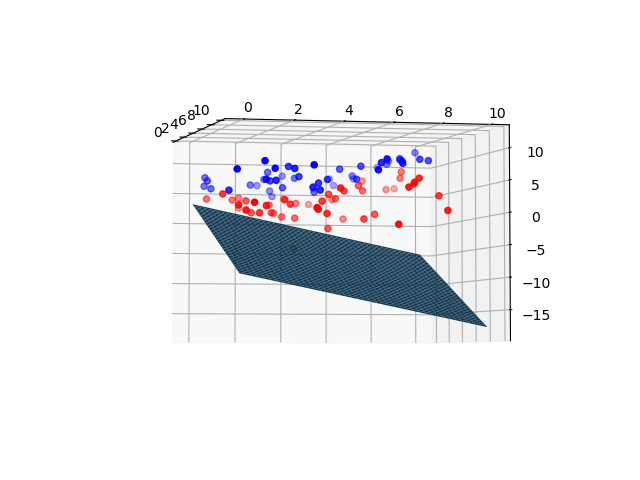

In [31]:
%matplotlib notebook

plt3d = plt.figure().gca(projection='3d')

xx, yy = np.meshgrid(np.linspace(0,10,41), np.linspace(0,10,41))

plt3d.plot_surface(xx, yy, p1);
plt3d.scatter(data.class0['x'], data.class0['y'], data.class0['z_plane'], color = 'r');
plt3d.scatter(data.class1['x'], data.class1['y'], data.class1['z_plane'], color = 'b');